In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd

from nibabel.processing import resample_to_output

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from resources.cut_off_edges import cut_off_edges
from resources.find_pitch_error_y_y import create_rotation_y_profile
from resources.find_rotation_error import create_rotation_x_profile
from resources.find_tilt_error import create_rotation_x_profile_tilt
from resources.find_x import calculate_x_profile
from resources.standarize_image import standardize_image

In [2]:
project_dir = Path.cwd().parents[1]

# Jeżeli notebook znajduje się np. w katalogu src:
if not (project_dir / "data").exists():
    project_dir = project_dir.parent

niftis_dir = project_dir / "data"
labels_path = niftis_dir / "niftis" /"train_labels_JNDlMjr.csv"

outputs_dir = project_dir / "src" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

labels_df = pd.read_csv(labels_path)

target_column = "is_pathologic"

labels = labels_df.set_index("uid")[target_column]

nifti_paths = sorted(niftis_dir.glob("*.nii.gz"))

print("Katalog projektu:", project_dir)
print("Liczba obrazów:", len(nifti_paths))
print("Liczba etykiet:", len(labels))


Katalog projektu: C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons
Liczba obrazów: 1362
Liczba etykiet: 1362


In [3]:
from notebooks.register_datscan_ants import register_to_template
from resources.find_z import calculate_z_profile
from resources.find_y import calculate_y_profile

uids = []
y_labels = []

x_profiles = []
y_profiles = []
z_profiles = []
rotation_x_profiles = []
pitch_y_profiles = []
tilt_x_profiles = []

for index, nifti_path in enumerate(nifti_paths, start=1):
    uid = nifti_path.name.removesuffix(".nii.gz")
    uid = uid.lstrip("_")
    if uid not in labels.index:
        print(f"Brak etykiety dla {uid}")
        continue

    print(f"{index}/{len(nifti_paths)}: {uid}")

    image = nib.load(nifti_path)

    volume = image.get_fdata(dtype=np.float32)

    profile_only_x = np.asarray(
        calculate_x_profile(volume),
        dtype=np.float32,
    )
    profile_only_y = np.asarray(
        calculate_y_profile(volume),
        dtype=np.float32,
    )
    profile_only_z = np.asarray(
        calculate_z_profile(volume),
        dtype=np.float32,
    )

    profile_rotation_x = np.asarray(
        create_rotation_x_profile(image),
        dtype=np.float32,
    )

    profile_pitch_y = np.asarray(
        create_rotation_y_profile(image),
        dtype=np.float32,
    )
    profile_tilt_x = np.asarray(
        create_rotation_x_profile_tilt(image),
        dtype=np.float32,
    )
    uids.append(uid)
    y_labels.append(int(labels.loc[uid]))

    x_profiles.append(profile_only_x)
    y_profiles.append(profile_only_y)
    z_profiles.append(profile_only_z)
    rotation_x_profiles.append(profile_rotation_x)
    pitch_y_profiles.append(profile_pitch_y)
    tilt_x_profiles.append(profile_tilt_x)


1/1362: 01nouhtc
2/1362: 0224wk0y
3/1362: 049enulq
4/1362: 04x0qzfh


KeyboardInterrupt: 

In [ ]:
x_profiles = np.stack(x_profiles)
y_profiles = np.stack(y_profiles)
z_profiles = np.stack(z_profiles)
rotation_x_profiles = np.stack(rotation_x_profiles)
pitch_y_profiles = np.stack(pitch_y_profiles)
tilt_x_profiles = np.stack(tilt_x_profiles)

y_labels = np.asarray(y_labels, dtype=np.int8)
uids = np.asarray(uids)

In [ ]:
output_path = project_dir / "data" / "processed_profiles_by_similarity.npz"

np.savez_compressed(
    output_path,
    uid=uids,
    is_pathologic=y_labels,
    x_profile=x_profiles,
    y_profile=y_profiles,
    z_profile=z_profiles,
    rotation_x_profile=rotation_x_profiles,
    tilt_x_profiles=tilt_x_profiles,
    pitch_y_profiles=pitch_y_profiles,
)

In [3]:
data = np.load(
    project_dir / "data" / "processed_profiles_by_similarity.npz",
    allow_pickle=False,
)
print(data.files)
uids = data["uid"]
y = data["is_pathologic"]

x_profile=data['x_profile']
y_profile=data['y_profile']
z_profile=data['z_profile']
rotation_x_profile=data['rotation_x_profile']
tilt_x_profiles=data['tilt_x_profiles']
pitch_y_profiles=data['pitch_y_profiles']

X = np.concatenate(
    [
        x_profile,
        y_profile,
        z_profile,
        rotation_x_profile,
    ],
    axis=1,
)

['uid', 'is_pathologic', 'x_profile', 'y_profile', 'z_profile', 'rotation_x_profile', 'tilt_x_profiles', 'pitch_y_profiles']


In [4]:
X_train, X_test, y_train, y_test, uid_train, uid_test = train_test_split(
    X,
    y,
    uids,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", np.unique(y_train, return_counts=True))
print("y_test:", np.unique(y_test, return_counts=True))
print("uid_train:", uid_train.shape)
print("uid_test:", uid_test.shape)

X_train: (1089, 495)
X_test: (273, 495)
y_train: (array([0, 1], dtype=int8), array([492, 597]))
y_test: (array([0, 1], dtype=int8), array([123, 150]))
uid_train: (1089,)
uid_test: (273,)


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=20_000,
        random_state=42,
    ),
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

param_grid = {
    "logisticregression__C": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
    ],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy CV log loss:", -grid_search.best_score_)

best_model = grid_search.best_estimator_

# pipeline = Pipeline([
#     (
#         "model",
#         RandomForestClassifier(
#             random_state=42,
#             n_jobs=1,
#         ),
#     ),
# ])
#
# param_distributions = {
#     "model__n_estimators": [300, 500, 800, 1000],
#     "model__max_depth": [None, 5, 10, 15, 20],
#     "model__min_samples_split": [2, 5, 10, 20],
#     "model__min_samples_leaf": [1, 2, 4, 8],
#     "model__max_features": ["sqrt", "log2", 0.5],
#     "model__criterion": ["gini", "entropy", "log_loss"],
# }
#
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42,
# )
#
# random_search = RandomizedSearchCV(
#     estimator=pipeline,
#     param_distributions=param_distributions,
#     n_iter=50,
#     scoring="neg_log_loss",
#     cv=cv,
#     n_jobs=-1,
#     random_state=42,
#     verbose=2,
#     return_train_score=True,
# )
#
# random_search.fit(X_train, y_train)
#
# print("Najlepsze parametry:")
# print(random_search.best_params_)
#
# print("Najlepszy CV log loss:")
# print(-random_search.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Najlepsze parametry: {'logisticregression__C': 0.1}
Najlepszy CV log loss: 0.44667914509773254


In [6]:
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_probability))
print("Log loss:", log_loss(y_test, y_probability))

print("\nMacierz omyłek:")
print(confusion_matrix(y_test, y_pred))

print("\nRaport:")
print(classification_report(y_test, y_pred))

eps = 1e-15

case_loss = -(
    y_test * np.log(np.clip(y_probability, eps, 1 - eps))
    + (1 - y_test) * np.log(np.clip(1 - y_probability, eps, 1 - eps))
)

analysis_df = pd.DataFrame({
    "uid": uid_test,
    "y_true": y_test,
    "probability": y_probability,
    "prediction": y_pred,
    "case_loss": case_loss,
    "is_error": y_test != y_pred,
})

analysis_df["error_type"] = np.where(
    (analysis_df["y_true"] == 0) & (analysis_df["prediction"] == 1),
    "false_positive",
    np.where(
        (analysis_df["y_true"] == 1) & (analysis_df["prediction"] == 0),
        "false_negative",
        "correct",
    ),
)

analysis_df.sort_values("case_loss", ascending=False).head(30)

Accuracy: 0.7985347985347986
F1: 0.8220064724919094
ROC AUC: 0.8904065040650406
Log loss: 0.42750197649002075

Macierz omyłek:
[[ 91  32]
 [ 23 127]]

Raport:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       123
           1       0.80      0.85      0.82       150

    accuracy                           0.80       273
   macro avg       0.80      0.79      0.79       273
weighted avg       0.80      0.80      0.80       273



,uid,y_true,probability,prediction,case_loss,is_error,error_type
7,4isotn9u,0,0.986643,1,4.315694,True,false_positive
149,0sqcnf9w,0,0.981436,1,3.986529,True,false_positive
196,yjoaoejv,1,0.033761,0,3.388462,True,false_negative
79,ivxan25w,1,0.086057,0,2.452742,True,false_negative
12,sajhjxqk,0,0.880664,1,2.125809,True,false_positive
156,0imjyjcm,1,0.120587,0,2.115386,True,false_negative
10,btgdjz0i,0,0.873659,1,2.068773,True,false_positive
154,82n2atqy,0,0.864805,1,2.001035,True,false_positive
120,fs6hn95s,1,0.149958,0,1.897398,True,false_negative
71,ofwb0hpm,0,0.849226,1,1.891973,True,false_positive


In [7]:
import copy
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32,
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32,
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32,
)
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

In [8]:
class ProfileMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 1024),
            nn.LayerNorm(1024),
            nn.Mish(),
            nn.Dropout(0.3),

            nn.Linear(1024, 128),
            nn.LayerNorm(128),
            nn.Mish(),
            nn.Dropout(0.3),

            nn.Linear(128, 32),
            nn.LayerNorm(32),
            nn.Mish(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ProfileMLP(
    input_size=X_train.shape[1],
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001,
)

print(model)
print("Urządzenie:", device)

ProfileMLP(
  (network): Sequential(
    (0): Linear(in_features=495, out_features=1024, bias=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): Mish()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=128, bias=True)
    (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (6): Mish()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=32, bias=True)
    (9): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (10): Mish()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Urządzenie: cuda


In [10]:
epochs = 2000
patience = 500

best_validation_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

epochs_without_improvement = 0

for epoch in range(epochs):
    # Trening
    model.train()

    train_loss_sum = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * len(X_batch)
        train_samples += len(X_batch)

    train_loss = train_loss_sum / train_samples

    # Walidacja
    model.eval()

    validation_loss_sum = 0.0
    validation_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            validation_loss_sum += loss.item() * len(X_batch)
            validation_samples += len(X_batch)

    validation_loss = (
        validation_loss_sum / validation_samples
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoka {epoch + 1:3d}/{epochs} | "
        f"train: {train_loss:.4f} | "
        f"validation: {validation_loss:.4f} | "
        f"best: {best_validation_loss:.4f}"
    )

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    logits = model(
        X_test_tensor.to(device)
    )

    probabilities = torch.sigmoid(logits)
    probabilities = probabilities.cpu().numpy()

predictions = (probabilities >= 0.5).astype(int)

print(
    "Log loss:",
    log_loss(y_test, probabilities),
)

print(
    "Accuracy:",
    accuracy_score(y_test, predictions),
)

Epoka   1/2000 | train: 0.6925 | validation: 0.6724 | best: 0.6724
Epoka   2/2000 | train: 0.6786 | validation: 0.6493 | best: 0.6493
Epoka   3/2000 | train: 0.6595 | validation: 0.6298 | best: 0.6298
Epoka   4/2000 | train: 0.6214 | validation: 0.6170 | best: 0.6170
Epoka   5/2000 | train: 0.6117 | validation: 0.6202 | best: 0.6170
Epoka   6/2000 | train: 0.6044 | validation: 0.5877 | best: 0.5877
Epoka   7/2000 | train: 0.5848 | validation: 0.6276 | best: 0.5877
Epoka   8/2000 | train: 0.6195 | validation: 0.5938 | best: 0.5877
Epoka   9/2000 | train: 0.5936 | validation: 0.5784 | best: 0.5784
Epoka  10/2000 | train: 0.5694 | validation: 0.5692 | best: 0.5692
Epoka  11/2000 | train: 0.5585 | validation: 0.5548 | best: 0.5548
Epoka  12/2000 | train: 0.5512 | validation: 0.5516 | best: 0.5516
Epoka  13/2000 | train: 0.5609 | validation: 0.5689 | best: 0.5516
Epoka  14/2000 | train: 0.5493 | validation: 0.6619 | best: 0.5516
Epoka  15/2000 | train: 0.5804 | validation: 0.5822 | best: 0.

Log loss: 0.419651061296463
Accuracy: 0.8058608058608059
F1: 0.8166089965397924
ROC AUC: 0.8960433604336043

Macierz omyłek:
[[102  21]
 [ 32 118]]

Raport:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       123
           1       0.85      0.79      0.82       150

    accuracy                           0.81       273
   macro avg       0.81      0.81      0.81       273
weighted avg       0.81      0.81      0.81       273



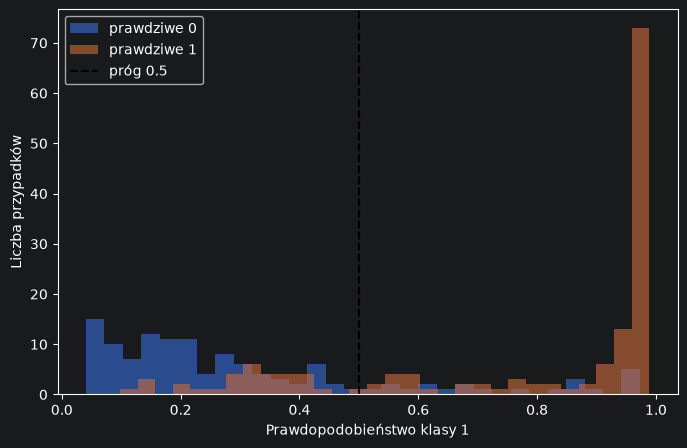

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    logits = model(
        X_test_tensor.to(device)
    )

probabilities = torch.sigmoid(logits).cpu().numpy().reshape(-1)
predictions = (probabilities >= 0.5).astype(int)

y_true = np.asarray(y_test).reshape(-1).astype(int)

print(
    "Log loss:",
    log_loss(y_true, probabilities),
)

print(
    "Accuracy:",
    accuracy_score(y_true, predictions),
)

print(
    "F1:",
    f1_score(y_true, predictions),
)

print(
    "ROC AUC:",
    roc_auc_score(y_true, probabilities),
)

print("\nMacierz omyłek:")
print(confusion_matrix(y_true, predictions))

print("\nRaport:")
print(classification_report(y_true, predictions))

plt.figure(figsize=(8, 5))

plt.hist(
    probabilities[y_true == 0],
    bins=30,
    alpha=0.6,
    label="prawdziwe 0",
)

plt.hist(
    probabilities[y_true == 1],
    bins=30,
    alpha=0.6,
    label="prawdziwe 1",
)

plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    label="próg 0.5",
)

plt.xlabel("Prawdopodobieństwo klasy 1")
plt.ylabel("Liczba przypadków")
plt.legend()
plt.show()

In [12]:
import pandas as pd
import numpy as np

eps = 1e-15

case_loss = -(
    y_true * np.log(np.clip(probabilities, eps, 1 - eps))
    + (1 - y_true) * np.log(np.clip(1 - probabilities, eps, 1 - eps))
)

analysis_df = pd.DataFrame({
    "uid": uid_test,
    "y_true": y_true,
    "probability": probabilities,
    "prediction": predictions,
    "case_loss": case_loss,
    "is_error": y_true != predictions,
})

analysis_df["confidence"] = np.where(
    analysis_df["probability"] >= 0.5,
    analysis_df["probability"],
    1 - analysis_df["probability"],
)

analysis_df["error_type"] = np.where(
    (analysis_df["y_true"] == 0) & (analysis_df["prediction"] == 1),
    "false_positive",
    np.where(
        (analysis_df["y_true"] == 1) & (analysis_df["prediction"] == 0),
        "false_negative",
        "correct",
    ),
)

analysis_df.sort_values("case_loss", ascending=False).head(30)

,uid,y_true,probability,prediction,case_loss,is_error,confidence,error_type
7,4isotn9u,0,0.973095,1,3.615459,True,0.973095,false_positive
12,sajhjxqk,0,0.968126,1,3.445950,True,0.968126,false_positive
173,cd31nrxd,0,0.964938,1,3.350639,True,0.964938,false_positive
241,3m9iqbq9,0,0.964261,1,3.331513,True,0.964261,false_positive
149,0sqcnf9w,0,0.961982,1,3.269686,True,0.961982,false_positive
79,ivxan25w,1,0.097710,0,2.325755,True,0.902290,false_negative
10,btgdjz0i,0,0.898250,1,2.285239,True,0.898250,false_positive
204,qyz6y3z1,0,0.875011,1,2.079529,True,0.875011,false_positive
196,yjoaoejv,1,0.128494,0,2.051870,True,0.871506,false_negative
120,fs6hn95s,1,0.136439,0,1.991877,True,0.863561,false_negative


In [13]:
from pathlib import Path
import torch

model.load_state_dict(best_model_state)
model.eval()

PROFILE_MODEL_PATH = (
    Path.cwd()
    / "profile_model.pth"
)

torch.save(
    model.state_dict(),
    PROFILE_MODEL_PATH,
)

print("Zapisano model:", PROFILE_MODEL_PATH)

Zapisano model: C:\Users\abram\PycharmProjects\DrivenData_DAT_Parkinsons\src\notebooks\EDA6\profile_model.pth
